## Deep Learning Based Intrusion Detection using CICIDS2017 Dataset

Bu çalışmada CICIDS2017 veri seti üzerinde derin öğrenme tabanlı sınıflandırma modelleri uygulanacaktır.

Notebook kapsamında aşağıdaki modeller incelenecektir:

- Deep Neural Network (DNN)
- Recurrent Neural Network (RNN)
- Long Short-Term Memory (LSTM)
- Gated Recurrent Unit (GRU)
- Bidirectional LSTM (BiLSTM)
- Bidirectional GRU (BiGRU)

Modeller performans metrikleri kullanılarak karşılaştırılacaktır.

Yapay Sinir Ağı (Artificial Neural Network) nedir?

Bir yapay sinir ağı, birbirine bağlı yapay nöronlardan oluşur. Her nöron giriş verilerini alır, ağırlıklar ile çarpar, bias değerini ekler ve aktivasyon fonksiyonundan geçirerek çıktı üretir.

Önce kütüphaneleri import ediyoruz.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

In [14]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

def evaluate_model(model_name, y_true, y_pred):

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    recall = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

    print("=" * 50)
    print(f"Model: {model_name}")
    print("=" * 50)

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-Score : {f1:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, zero_division=0))

In [4]:
X_train = pd.read_csv("../data/X_train.csv")
X_test = pd.read_csv("../data/X_test.csv")

y_train = pd.read_csv("../data/y_train.csv").squeeze()
y_test = pd.read_csv("../data/y_test.csv").squeeze()

One-Hot Encoding

Metinsel veya kategorik verileri (örn: renkler, cinsiyet) makine öğrenmesi algoritmalarının anlayabileceği ikili (binary: 0 ve 1) sayılara dönüştüren bir veri ön işleme tekniğidir. Her kategori için ayrı bir sütun oluşturulur ve ilgili verinin olduğu sütuna 1, diğerlerine 0 yazılır.

In [5]:
from tensorflow.keras.utils import to_categorical

y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

print(y_train_cat.shape)
print(y_test_cat.shape)

print(y_train_cat[0])

(452465, 15)
(113117, 15)
[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


İlk DNN Modeli

Sequential: Katmanları sırayla oluşturacağımızı söylüyor.

İlk katman

Dense(128, activation="relu") -> 128 nöron ReLU aktivasyon fonksiyonu

input_shape=(X_train.shape[1],)

Bizde 78 özellik olduğu için model girişte 78 özellik bekliyor.

İkinci katman

Dense(64, activation="relu") -> İlk katmandan gelen bilgileri daha soyut hale getiriyor.

Çıkış katmanı

Dense(
    y_train_cat.shape[1],
    activation="softmax"
)

Bizde 15 sınıf olduğu için çıktı 15 nöron olacak. Softmax ise bunları olasılığa çeviriyor. Örneğin BENIGN 0.97, DoS 0.02, Bot 0.01 gibi.

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

dnn_model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(128, activation="relu"),
    Dense(64, activation="relu"),
    Dense(y_train_cat.shape[1], activation="softmax")
])

In [8]:
dnn_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

dnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │        10,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 15)             │           975 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,343 (75.56 KB)

 Trainable params: 19,343 (75.56 KB)

 Non-trainable params: 0 (0.00 B)

- TensorFlow GPU support is not available... uyarısı -> "GPU kullanmayacağım, CPU ile çalışacağım."

- dense_3
(None,128)
İlk gizli katmanda 128 nöron var demektir.

- (None,64)
Dense(64)
Yani ikinci katmanda 64 nöron var.

- (None,15)
Bizim 15 sınıfımız vardı. O yüzden çıktıda 15 nöron oluyor. Her nöron bir sınıfı temsil ediyor.

- Param # ne?
Mesela 10112 modelin öğreneceği sayı adedi.
Yani kaç tane ağırlık (weight) ve kaç tane bias öğreneceğini gösteriyor.

- Nereden geliyor? İlk katmanda 78 giriş vardı. Her giriş 128 nörona bağlanıyor.
78 × 128 = 9984
Bir de 128 bias var. 9984 + 128 = 10112
İkinci katman da aynı mantık. 128 × 64 + 64 bias = 8256
Son katman 64 × 15 + 15 = 975
78 özellik -> 128 nöron -> 64 nöron -> 15 sınıf ve toplam 19343 öğrenilecek parametre var.

Modeli eğitiyoruz.

Parametreler:

- epochs=10 -> Model tüm eğitim verisini 10 kez görecek.

- batch_size=64 -> 452 bin satırı tek seferde vermiyoruz. 64'erli gruplar halinde veriyoruz.
Böylece bellek daha verimli kullanılır, eğitim daha hızlı olur.

- validation_split=0.2 -> Eğitim verisinin %20'si doğrulama (validation) için ayrılır. Yani: X_train -> %80 Eğitim %20 Validation. Validation verisi öğrenmek için kullanılmaz. Sadece modelin eğitim sırasında ne kadar iyi genelleme yaptığını görmek için kullanılır.

- verbose=1 -> Epoch ilerlemesini ekrana yazdırır.

In [9]:
history = dnn_model.fit(
    X_train,
    y_train_cat,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
5656/5656 ━━━━━━━━━━━━━━━━━━━━ 30s 5ms/step - accuracy: 0.8942 - loss: 27343.5059 - val_accuracy: 0.8907 - val_loss: 1748.5900
Epoch 2/10
5656/5656 ━━━━━━━━━━━━━━━━━━━━ 35s 6ms/step - accuracy: 0.8661 - loss: 399.1150 - val_accuracy: 0.8468 - val_loss: 4.8375
Epoch 3/10
5656/5656 ━━━━━━━━━━━━━━━━━━━━ 34s 6ms/step - accuracy: 0.8251 - loss: 4.9381 - val_accuracy: 0.8030 - val_loss: 26.6285
Epoch 4/10
5656/5656 ━━━━━━━━━━━━━━━━━━━━ 23s 4ms/step - accuracy: 0.8031 - loss: 1.4961 - val_accuracy: 0.8033 - val_loss: 0.7551
Epoch 5/10
5656/5656 ━━━━━━━━━━━━━━━━━━━━ 22s 4ms/step - accuracy: 0.8033 - loss: 0.7648 - val_accuracy: 0.8032 - val_loss: 0.7566
Epoch 6/10
5656/5656 ━━━━━━━━━━━━━━━━━━━━ 21s 4ms/step - accuracy: 0.8032 - loss: 0.7755 - val_accuracy: 0.8032 - val_loss: 0.7559
Epoch 7/10
5656/5656 ━━━━━━━━━━━━━━━━━━━━ 22s 4ms/step - accuracy: 0.8031 - loss: 0.8111 - val_accuracy: 0.8032 - val_loss: 0.7558
Epoch 8/10
5656/5656 ━━━━━━━━━━━━━━━━━━━━ 22s 4ms/step - accuracy: 0.8032

Eğitim Grafikleri

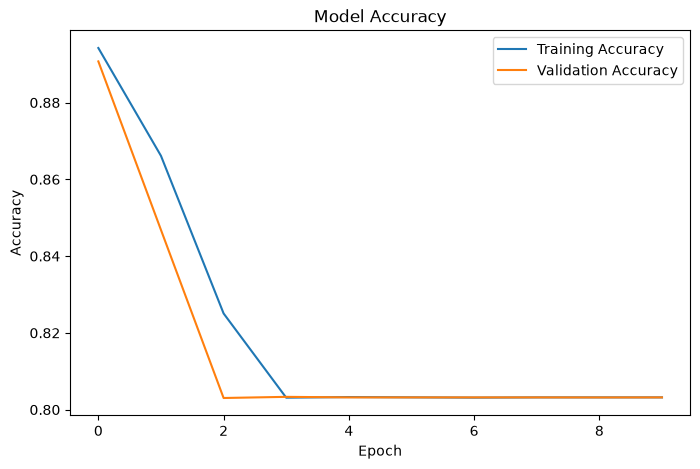

In [10]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

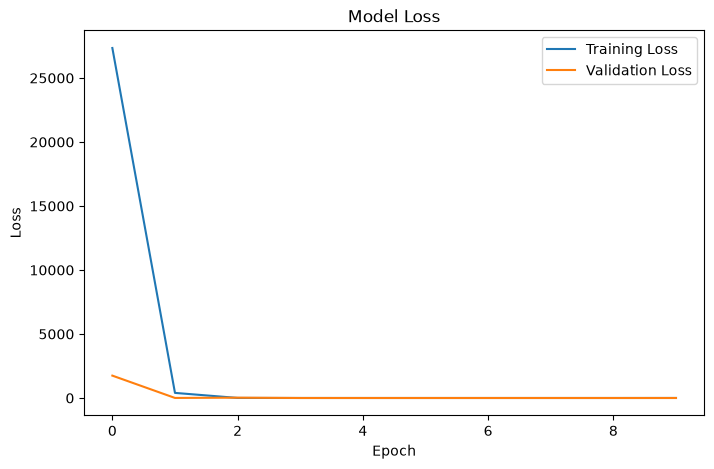

In [11]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

Test Verisi Üzerinde Tahmin

DNN'nin çıktısı sınıf numarası değil, olasılık vektörüdür. Bu yüzden önce en yüksek olasılığa sahip sınıfı bulacağız.

In [12]:
dnn_probabilities = dnn_model.predict(X_test)

dnn_predictions = np.argmax(dnn_probabilities, axis=1)

3535/3535 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step


Performans Değerlendirmesi

Notebook başındaki evaluate_model() fonksiyonunu aynen kullanıyoruz.

In [15]:
evaluate_model(
    model_name="DNN",
    y_true=y_test,
    y_pred=dnn_predictions
)

Model: DNN
Accuracy : 0.8032
Precision: 0.6451
Recall   : 0.8032
F1-Score : 0.7155

Classification Report:
              precision    recall  f1-score   support

           0       0.80      1.00      0.89     90855
           1       0.00      0.00      0.00        78
           2       0.00      0.00      0.00      5121
           3       0.00      0.00      0.00       412
           4       0.00      0.00      0.00      9205
           5       0.00      0.00      0.00       220
           6       0.00      0.00      0.00       232
           7       0.00      0.00      0.00       317
           9       0.00      0.00      0.00         1
          10       0.00      0.00      0.00      6353
          11       0.00      0.00      0.00       236
          12       0.00      0.00      0.00        60
          13       0.00      0.00      0.00         1
          14       0.00      0.00      0.00        26

    accuracy                           0.80    113117
   macro avg       0.06    

DNN Sonuçlarının Değerlendirilmesi

DNN modeli yüksek doğruluk değerine ulaşmasına rağmen azınlık sınıflarını başarılı şekilde öğrenememiştir. Veri setindeki sınıf dengesizliği nedeniyle model çoğunluk sınıfına yönelmiş ve saldırı sınıflarının büyük kısmını doğru tahmin edememiştir. Bu durum yalnızca doğruluk (Accuracy) metriğinin yeterli olmadığını, Precision, Recall ve F1-Score gibi metriklerin de birlikte değerlendirilmesi gerektiğini göstermektedir.

## RNN (Recurrent Neural Network)

Türkçeye "Tekrarlayan Sinir Ağı" veya "Yinelemeli Sinir Ağı" olarak çevrilen bu mimari, verileri sırayla işleyen ve geçmiş bilgileri hafızasında tutarak kararlar alan bir yapay zeka modelidir. 

Klasik yapay sinir ağları her girdiyi birbirinden bağımsız değerlendirirken, RNN'ler içsel döngüleri sayesinde bir cümledeki önceki kelimeleri veya bir zaman serisindeki geçmiş verileri hatırlar. Bu hafıza yeteneği; dillerdeki yapısal bağlamı anlamasını, konuşmaları metne dökmesini ve geleceğe yönelik borsa veya hava durumu gibi zaman odaklı tahminler yapmasını sağlar.

RNN, DNN gibi (452465, 78) veri kabul etmediği için ilk olarak dönüştürmemiz gerekiyor.

(örnek_sayısı,
 zaman_adımı,
 özellik_sayısı)

In [16]:
X_train_rnn = X_train.values.reshape(X_train.shape[0], 1, X_train.shape[1])

X_test_rnn = X_test.values.reshape(X_test.shape[0], 1, X_test.shape[1])

print(X_train_rnn.shape)
print(X_test_rnn.shape)

(452465, 1, 78)
(113117, 1, 78)


RNN her örneği 1 zaman adımı -> 78 özellik olarak görecek.

Normalde RNN 10 zaman adımı -> 50 zaman adımı -> 100 zaman adımı gibi dizilerle çalışır. Bizim verimizde zaman dizisi olmadığı için 1 zaman adımı kullanıyoruz.

RNN'nin amacı bir olayın zaman içinde nasıl değiştiğini öğrenmektir.

Mesela hava durumu:

- Pazartesi  → 20°C
- Salı       → 22°C
- Çarşamba   → 25°C
- Perşembe   → 24°C

Burada 4 zaman adımı (time step) var. Şekli: (4 zaman adımı, 1 özellik) 

Bir başka örnek ise cümle "Ben" -> "bugün" -> "okula" -> "gittim"

Burada da
"Ben" = 1. zaman adımı
"bugün" = 2. zaman adımı
"okula" = 3. zaman adımı
"gittim" = 4. zaman adımı

RNN bunları sırayla okur.

Peki neden (1, 78) yaptık?

Çünkü Keras'ın SimpleRNN, LSTM, GRU katmanları mutlaka 3 boyutlu veri bekler.

Beklediği format:
(örnek sayısı,
 zaman adımı,
 özellik sayısı)

Bizde gerçek zaman dizisi olmadığı için yapay olarak: 1 zaman adımı -> 78 özellik diyoruz.

Yani her bağlantıyı sanki tek zaman anında ölçülmüş bir gözlem gibi gösteriyoruz.

Bu yüzden: X_train.shape önceden (452465, 78) iken şimdi (452465, 1, 78) oldu.

In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, SimpleRNN, Dense

rnn_model = Sequential([
    Input(shape=(1, X_train.shape[1])),
    SimpleRNN(64, activation="tanh"),
    Dense(y_train_cat.shape[1], activation="softmax")
])

SimpleRNN(64, activation="tanh") bu satırın anlamı: 64 → RNN katmanındaki nöron sayısı.

tanh → RNN'lerde en sık kullanılan aktivasyon fonksiyonu. ReLU değil çünkü klasik RNN mimarisi genellikle tanh ile çalışacak şekilde tasarlanmıştır. LSTM ve GRU da varsayılan olarak tanh kullanır.

In [18]:
rnn_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [19]:
rnn_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         9,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 15)             │           975 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,127 (39.56 KB)

 Trainable params: 10,127 (39.56 KB)

 Non-trainable params: 0 (0.00 B)

Eğitim ve sonrasında tahmin

In [20]:
history_rnn = rnn_model.fit(
    X_train_rnn,
    y_train_cat,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
5656/5656 ━━━━━━━━━━━━━━━━━━━━ 38s 6ms/step - accuracy: 0.8845 - loss: 0.3331 - val_accuracy: 0.8995 - val_loss: 0.2811
Epoch 2/10
5656/5656 ━━━━━━━━━━━━━━━━━━━━ 23s 4ms/step - accuracy: 0.8849 - loss: 0.3128 - val_accuracy: 0.8766 - val_loss: 0.3057
Epoch 3/10
5656/5656 ━━━━━━━━━━━━━━━━━━━━ 22s 4ms/step - accuracy: 0.8876 - loss: 0.2975 - val_accuracy: 0.8951 - val_loss: 0.2929
Epoch 4/10
5656/5656 ━━━━━━━━━━━━━━━━━━━━ 22s 4ms/step - accuracy: 0.8925 - loss: 0.2925 - val_accuracy: 0.8803 - val_loss: 0.3197
Epoch 5/10
5656/5656 ━━━━━━━━━━━━━━━━━━━━ 24s 4ms/step - accuracy: 0.8872 - loss: 0.2984 - val_accuracy: 0.8896 - val_loss: 0.2843
Epoch 6/10
5656/5656 ━━━━━━━━━━━━━━━━━━━━ 23s 4ms/step - accuracy: 0.8824 - loss: 0.3021 - val_accuracy: 0.8995 - val_loss: 0.2832
Epoch 7/10
5656/5656 ━━━━━━━━━━━━━━━━━━━━ 23s 4ms/step - accuracy: 0.8865 - loss: 0.2882 - val_accuracy: 0.8945 - val_loss: 0.2748
Epoch 8/10
5656/5656 ━━━━━━━━━━━━━━━━━━━━ 22s 4ms/step - accuracy: 0.8946 - loss: 0

In [21]:
rnn_probabilities = rnn_model.predict(X_test_rnn)

rnn_predictions = np.argmax(rnn_probabilities, axis=1)

3535/3535 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step


In [22]:
evaluate_model(
    model_name="RNN",
    y_true=y_test,
    y_pred=rnn_predictions
)

Model: RNN
Accuracy : 0.8944
Precision: 0.8883
Recall   : 0.8944
F1-Score : 0.8886

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.94      0.94     90855
           1       0.00      0.00      0.00        78
           2       0.73      0.75      0.74      5121
           3       0.62      0.04      0.07       412
           4       0.75      0.63      0.68      9205
           5       0.00      0.00      0.00       220
           6       0.00      0.00      0.00       232
           7       0.00      0.00      0.00       317
           9       0.00      0.00      0.00         1
          10       0.67      0.96      0.79      6353
          11       0.00      0.00      0.00       236
          12       0.00      0.00      0.00        60
          13       0.00      0.00      0.00         1
          14       0.00      0.00      0.00        26

    accuracy                           0.89    113117
   macro avg       0.26    

RNN Sonuçlarının Değerlendirilmesi

RNN modeli DNN'e göre daha yüksek doğruluk ve F1-Score elde etmiştir. Özellikle veri setindeki büyük sınıfları daha başarılı şekilde öğrenmiştir. Ancak veri setindeki sınıf dengesizliği nedeniyle örnek sayısı çok az olan saldırı türlerinde performans düşük kalmıştır.

## LSTM

RNN eski bilgileri zamanla unutabilir. LSTM ise hangi bilgiyi hatırlayacağını, hangisini unutacağını kendisi öğrenir. Bu yüzden uzun zaman dizilerinde RNN'den daha başarılıdır.

Kod olarak neredeyse aynılar.

In [23]:
from tensorflow.keras.layers import LSTM

In [24]:
lstm_model = Sequential([
    Input(shape=(1, X_train.shape[1])),
    LSTM(64),
    Dense(y_train_cat.shape[1], activation="softmax")
])

In [25]:
lstm_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [27]:
history_lstm = lstm_model.fit(
    X_train_rnn,
    y_train_cat,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
5656/5656 ━━━━━━━━━━━━━━━━━━━━ 26s 5ms/step - accuracy: 0.8932 - loss: 0.3051 - val_accuracy: 0.8774 - val_loss: 0.3346
Epoch 2/10
5656/5656 ━━━━━━━━━━━━━━━━━━━━ 26s 5ms/step - accuracy: 0.8821 - loss: 0.3434 - val_accuracy: 0.8751 - val_loss: 0.3362
Epoch 3/10
5656/5656 ━━━━━━━━━━━━━━━━━━━━ 25s 4ms/step - accuracy: 0.8790 - loss: 0.3368 - val_accuracy: 0.8894 - val_loss: 0.3196
Epoch 4/10
5656/5656 ━━━━━━━━━━━━━━━━━━━━ 25s 4ms/step - accuracy: 0.8812 - loss: 0.3367 - val_accuracy: 0.8834 - val_loss: 0.3283
Epoch 5/10
5656/5656 ━━━━━━━━━━━━━━━━━━━━ 26s 5ms/step - accuracy: 0.8930 - loss: 0.3145 - val_accuracy: 0.9029 - val_loss: 0.2990
Epoch 6/10
5656/5656 ━━━━━━━━━━━━━━━━━━━━ 27s 5ms/step - accuracy: 0.9000 - loss: 0.2888 - val_accuracy: 0.9043 - val_loss: 0.2970
Epoch 7/10
5656/5656 ━━━━━━━━━━━━━━━━━━━━ 26s 5ms/step - accuracy: 0.8935 - loss: 0.2988 - val_accuracy: 0.9054 - val_loss: 0.2902
Epoch 8/10
5656/5656 ━━━━━━━━━━━━━━━━━━━━ 27s 5ms/step - accuracy: 0.8951 - loss: 0

Model eğitildikten sonra test verisi üzerinde tahmin işlemi gerçekleştirilmiştir. `predict()` fonksiyonu her örnek için sınıflara ait olasılık değerlerini üretmektedir. Daha sonra `np.argmax()` fonksiyonu kullanılarak en yüksek olasılığa sahip sınıf seçilmiş ve nihai tahmin etiketi elde edilmiştir.

In [28]:
lstm_predictions = np.argmax(
    lstm_model.predict(X_test_rnn),
    axis=1
)

3535/3535 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step


In [29]:
evaluate_model(
    model_name="LSTM",
    y_true=y_test,
    y_pred=lstm_predictions
)

Model: LSTM
Accuracy : 0.9145
Precision: 0.9112
Recall   : 0.9145
F1-Score : 0.9102

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.94      0.95     90855
           1       0.00      0.00      0.00        78
           2       0.85      0.72      0.78      5121
           3       0.62      0.04      0.07       412
           4       0.68      0.85      0.75      9205
           5       0.00      0.00      0.00       220
           6       0.00      0.00      0.00       232
           7       0.00      0.00      0.00       317
           9       0.00      0.00      0.00         1
          10       0.78      0.98      0.87      6353
          11       0.00      0.00      0.00       236
          12       0.00      0.00      0.00        60
          13       0.00      0.00      0.00         1
          14       0.00      0.00      0.00        26

    accuracy                           0.91    113117
   macro avg       0.28   

LSTM Sonuçlarının Değerlendirilmesi

LSTM modeli, DNN ve RNN modellerine kıyasla daha yüksek doğruluk ve F1-Score değerleri elde etmiştir. Model özellikle veri setindeki büyük sınıfları daha başarılı şekilde öğrenmiştir. Ancak veri setindeki sınıf dengesizliği nedeniyle örnek sayısı oldukça az olan saldırı türlerinde performansın düşük kaldığı görülmüştür. Bu sonuçlar, LSTM'nin uzun süreli bağımlılıkları öğrenme yeteneğinin modele olumlu katkı sağladığını göstermektedir.

## GRU (Gated Recurrent Unit - Kapılı Tekrarlayan Birim)

Standart RNN'lerin uzun vadeli hafıza sorununu çözmek için geliştirilmiş gelişmiş bir Tekrarlayan Sinir Ağı mimarisidir. Geleneksel RNN'lerde görülen ve uzak geçmişteki bilgilerin unutulmasına yol açan kaybolan gradyan (vanishing gradient) problemini ortadan kaldırır. GRU, bilgiyi ne kadar süreyle koruyacağını veya ne zaman güncelleyeceğini özel "kapı" (gate) mekanizmalarıyla kontrol eder.

- GRU: Daha basittir, 2 kapısı vardır, hücre durumu (cell state) yoktur ve daha hızlı çalışır.
- LSTM: Daha karmaşıktır, 3 kapısı vardır, ayrı bir hücre durumu kullanır ve büyük verilerde daha etkilidir ancak daha yavaştır.

In [30]:
from tensorflow.keras.layers import GRU

In [31]:
gru_model = Sequential([
    Input(shape=(1, X_train.shape[1])),
    GRU(64),
    Dense(y_train_cat.shape[1], activation="softmax")
])

In [32]:
gru_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [33]:
gru_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        27,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 15)             │           975 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,623 (111.81 KB)

 Trainable params: 28,623 (111.81 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
history_gru = gru_model.fit(
    X_train_rnn,
    y_train_cat,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
5656/5656 ━━━━━━━━━━━━━━━━━━━━ 46s 8ms/step - accuracy: 0.8704 - loss: 0.3675 - val_accuracy: 0.8757 - val_loss: 0.3100
Epoch 2/10
5656/5656 ━━━━━━━━━━━━━━━━━━━━ 42s 7ms/step - accuracy: 0.8814 - loss: 0.3062 - val_accuracy: 0.8779 - val_loss: 0.3030
Epoch 3/10
5656/5656 ━━━━━━━━━━━━━━━━━━━━ 42s 7ms/step - accuracy: 0.8868 - loss: 0.3054 - val_accuracy: 0.8764 - val_loss: 0.3315
Epoch 4/10
5656/5656 ━━━━━━━━━━━━━━━━━━━━ 41s 7ms/step - accuracy: 0.8860 - loss: 0.3170 - val_accuracy: 0.8987 - val_loss: 0.3003
Epoch 5/10
5656/5656 ━━━━━━━━━━━━━━━━━━━━ 42s 7ms/step - accuracy: 0.8828 - loss: 0.3098 - val_accuracy: 0.8867 - val_loss: 0.2920
Epoch 6/10
5656/5656 ━━━━━━━━━━━━━━━━━━━━ 43s 8ms/step - accuracy: 0.8847 - loss: 0.3227 - val_accuracy: 0.8800 - val_loss: 0.3323
Epoch 7/10
5656/5656 ━━━━━━━━━━━━━━━━━━━━ 42s 7ms/step - accuracy: 0.8846 - loss: 0.3220 - val_accuracy: 0.8932 - val_loss: 0.3118
Epoch 8/10
5656/5656 ━━━━━━━━━━━━━━━━━━━━ 41s 7ms/step - accuracy: 0.8925 - loss: 0

In [35]:
gru_probabilities = gru_model.predict(X_test_rnn)

gru_predictions = np.argmax(gru_probabilities, axis=1)

3535/3535 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step


In [36]:
evaluate_model(
    model_name="GRU",
    y_true=y_test,
    y_pred=gru_predictions
)

Model: GRU
Accuracy : 0.8889
Precision: 0.8829
Recall   : 0.8889
F1-Score : 0.8804

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.95      0.94     90855
           1       0.00      0.00      0.00        78
           2       0.71      0.62      0.66      5121
           3       0.00      0.00      0.00       412
           4       0.63      0.82      0.71      9205
           5       0.00      0.00      0.00       220
           6       0.00      0.00      0.00       232
           7       0.00      0.00      0.00       317
           9       0.00      0.00      0.00         1
          10       0.97      0.50      0.66      6353
          11       0.00      0.00      0.00       236
          12       0.00      0.00      0.00        60
          13       0.00      0.00      0.00         1
          14       0.00      0.00      0.00        26

    accuracy                           0.89    113117
   macro avg       0.23    

GRU Sonuçlarının Değerlendirilmesi

GRU modeli DNN'e göre daha başarılı sonuçlar elde etmiş, ancak bu veri setinde LSTM ve RNN modellerinin gerisinde kalmıştır. Daha az parametreye sahip olması nedeniyle eğitim süresi daha kısa olmasına rağmen sınıf dengesizliğinden etkilendiği ve az örnek içeren saldırı türlerinde düşük performans gösterdiği gözlemlenmiştir.

## BiLSTM (Bidirectional Long Short-Term Memory - Çift Yönlü Uzun Kısa Vadeli Hafıza)

Standart LSTM modelleri veriyi sadece soldan sağa (geçmiştirten geleceğe) işlerken, BiLSTM veriyi hem soldan sağa hem de sağdan sola (hem geçmişten geleceğe hem gelecekten geçmişe) olmak üzere iki yönde aynı anda işler.

Çift Yönlü Ağ: Bir cümleyi okurken hem önceki kelimeleri hem de henüz okunmamış olan sonraki kelimeleri aynı anda hesaba katar. Bu sayede kelimelerin veya verilerin sadece geçmişteki değil, gelecekteki bağlamını da öğrenerek çok daha isabetli tahminler yapar.

In [37]:
from tensorflow.keras.layers import Bidirectional, LSTM

In [38]:
bilstm_model = Sequential([
    Input(shape=(1, X_train.shape[1])),
    Bidirectional(LSTM(64)),
    Dense(y_train_cat.shape[1], activation="softmax")
])

In [39]:
bilstm_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [40]:
bilstm_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 128)            │        73,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75,151 (293.56 KB)

 Trainable params: 75,151 (293.56 KB)

 Non-trainable params: 0 (0.00 B)

In [41]:
history_bilstm = bilstm_model.fit(
    X_train_rnn,
    y_train_cat,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
5656/5656 ━━━━━━━━━━━━━━━━━━━━ 35s 5ms/step - accuracy: 0.8755 - loss: 0.3498 - val_accuracy: 0.8899 - val_loss: 0.2802
Epoch 2/10
5656/5656 ━━━━━━━━━━━━━━━━━━━━ 30s 5ms/step - accuracy: 0.8851 - loss: 0.3008 - val_accuracy: 0.8872 - val_loss: 0.2960
Epoch 3/10
5656/5656 ━━━━━━━━━━━━━━━━━━━━ 28s 5ms/step - accuracy: 0.8955 - loss: 0.2795 - val_accuracy: 0.8999 - val_loss: 0.2809
Epoch 4/10
5656/5656 ━━━━━━━━━━━━━━━━━━━━ 30s 5ms/step - accuracy: 0.8822 - loss: 0.2957 - val_accuracy: 0.8803 - val_loss: 0.2823
Epoch 5/10
5656/5656 ━━━━━━━━━━━━━━━━━━━━ 29s 5ms/step - accuracy: 0.8933 - loss: 0.2813 - val_accuracy: 0.8993 - val_loss: 0.2788
Epoch 6/10
5656/5656 ━━━━━━━━━━━━━━━━━━━━ 30s 5ms/step - accuracy: 0.8984 - loss: 0.2750 - val_accuracy: 0.9023 - val_loss: 0.2534
Epoch 7/10
5656/5656 ━━━━━━━━━━━━━━━━━━━━ 41s 5ms/step - accuracy: 0.8862 - loss: 0.2924 - val_accuracy: 0.8848 - val_loss: 0.2970
Epoch 8/10
5656/5656 ━━━━━━━━━━━━━━━━━━━━ 31s 5ms/step - accuracy: 0.8866 - loss: 0

In [42]:
bilstm_probabilities = bilstm_model.predict(X_test_rnn)

bilstm_predictions = np.argmax(bilstm_probabilities, axis=1)

3535/3535 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step


In [43]:
evaluate_model(
    model_name="BiLSTM",
    y_true=y_test,
    y_pred=bilstm_predictions
)

Model: BiLSTM
Accuracy : 0.8906
Precision: 0.8913
Recall   : 0.8906
F1-Score : 0.8880

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.93      0.94     90855
           1       0.00      0.00      0.00        78
           2       0.79      0.57      0.66      5121
           3       0.28      0.02      0.04       412
           4       0.58      0.81      0.67      9205
           5       0.74      0.45      0.56       220
           6       0.00      0.00      0.00       232
           7       0.00      0.00      0.00       317
           8       0.00      0.00      0.00         0
           9       0.00      0.00      0.00         1
          10       0.79      0.89      0.83      6353
          11       0.00      0.00      0.00       236
          12       0.00      0.00      0.00        60
          13       0.00      0.00      0.00         1
          14       0.00      0.00      0.00        26

    accuracy            

BiLSTM Sonuçlarının Değerlendirilmesi

BiLSTM modeli veriyi hem ileri hem de geri yönde işleyerek çift yönlü öğrenme gerçekleştirmiştir. Ancak bu veri setinde elde edilen performans tek yönlü LSTM modelinin gerisinde kalmıştır. Bunun temel nedenlerinden biri, CICIDS2017 veri setinin zaman serisi yapısında olmaması ve çift yönlü öğrenmenin ek bir avantaj sağlamamasıdır.

## BiGRU (Bidirectional Gated Recurrent Unit - Çift Yönlü Kapılı Tekrarlayan Birim) 

BiGRU, standart GRU modelinin çift yönlü (bidirectional) çalışan versiyonudur. Tıpkı BiLSTM gibi, sıralı verileri hem baştan sona (soldan sağa) hem de sondan başa (sağdan sola) olmak üzere aynı anda iki yönde işler. Böylece veri setindeki bir öğenin hem geçmişindeki hem de geleceğindeki bağlamı aynı anda öğrenir.

BiGRU vs BiLSTM Neden Tercih Edilir?
- Daha Hızlıdır: GRU yapısı gereği LSTM'e göre daha az kapıya (2 kapı) ve parametreye sahip olduğundan, BiGRU modeli BiLSTM'e kıyasla daha hızlı eğitilir ve daha az donanım gücü tüketir.
- Daha Az Veri İster: BiLSTM kadar karmaşık olmadığı için, özellikle küçük ve orta ölçekli veri setlerinde aşırı öğrenmeye (overfitting) yakalanmadan çok başarılı sonuçlar verir.

In [44]:
from tensorflow.keras.layers import Bidirectional, GRU

In [45]:
bigru_model = Sequential([
    Input(shape=(1, X_train.shape[1])),
    Bidirectional(GRU(64)),
    Dense(y_train_cat.shape[1], activation="softmax")
])

In [46]:
bigru_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [47]:
bigru_model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_1 (Bidirectional) │ (None, 128)            │        55,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57,231 (223.56 KB)

 Trainable params: 57,231 (223.56 KB)

 Non-trainable params: 0 (0.00 B)

In [48]:
history_bigru = bigru_model.fit(
    X_train_rnn,
    y_train_cat,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
5656/5656 ━━━━━━━━━━━━━━━━━━━━ 37s 6ms/step - accuracy: 0.8907 - loss: 0.3077 - val_accuracy: 0.9005 - val_loss: 0.2738
Epoch 2/10
5656/5656 ━━━━━━━━━━━━━━━━━━━━ 30s 5ms/step - accuracy: 0.9024 - loss: 0.2668 - val_accuracy: 0.9102 - val_loss: 0.2592
Epoch 3/10
5656/5656 ━━━━━━━━━━━━━━━━━━━━ 31s 5ms/step - accuracy: 0.9030 - loss: 0.2671 - val_accuracy: 0.8964 - val_loss: 0.3022
Epoch 4/10
5656/5656 ━━━━━━━━━━━━━━━━━━━━ 29s 5ms/step - accuracy: 0.9028 - loss: 0.2617 - val_accuracy: 0.9161 - val_loss: 0.2248
Epoch 5/10
5656/5656 ━━━━━━━━━━━━━━━━━━━━ 31s 5ms/step - accuracy: 0.9085 - loss: 0.2510 - val_accuracy: 0.9087 - val_loss: 0.2454
Epoch 6/10
5656/5656 ━━━━━━━━━━━━━━━━━━━━ 31s 5ms/step - accuracy: 0.9079 - loss: 0.2588 - val_accuracy: 0.8882 - val_loss: 0.2761
Epoch 7/10
5656/5656 ━━━━━━━━━━━━━━━━━━━━ 32s 6ms/step - accuracy: 0.8996 - loss: 0.2707 - val_accuracy: 0.9064 - val_loss: 0.2661
Epoch 8/10
5656/5656 ━━━━━━━━━━━━━━━━━━━━ 30s 5ms/step - accuracy: 0.8987 - loss: 0

In [49]:
bigru_probabilities = bigru_model.predict(X_test_rnn)

bigru_predictions = np.argmax(bigru_probabilities, axis=1)

3535/3535 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step


In [50]:
evaluate_model(
    model_name="BiGRU",
    y_true=y_test,
    y_pred=bigru_predictions
)

Model: BiGRU
Accuracy : 0.9104
Precision: 0.9060
Recall   : 0.9104
F1-Score : 0.9050

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95     90855
           1       0.00      0.00      0.00        78
           2       0.81      0.52      0.63      5121
           3       0.00      0.00      0.00       412
           4       0.67      0.84      0.75      9205
           5       0.79      0.45      0.57       220
           6       0.00      0.00      0.00       232
           7       0.00      0.00      0.00       317
           9       0.00      0.00      0.00         1
          10       0.80      0.97      0.88      6353
          11       0.82      0.12      0.21       236
          12       0.00      0.00      0.00        60
          13       0.00      0.00      0.00         1
          14       0.00      0.00      0.00        26

    accuracy                           0.91    113117
   macro avg       0.35  

BiGRU Sonuçlarının Değerlendirilmesi

BiGRU modeli çift yönlü GRU yapısını kullanarak hem ileri hem de geri yönde öğrenme gerçekleştirmiştir. Elde edilen sonuçlar GRU modeline göre daha yüksek doğruluk ve F1-Score değerleri göstermiştir. Bununla birlikte veri setindeki sınıf dengesizliği nedeniyle az örneğe sahip saldırı türlerinde performansın düşük kaldığı gözlemlenmiştir.

In [51]:
deep_learning_results = pd.DataFrame({
    "Model": [
        "DNN",
        "RNN",
        "LSTM",
        "GRU",
        "BiLSTM",
        "BiGRU"
    ],
    "Accuracy": [
        0.8032,
        0.8944,
        0.9145,
        0.8889,
        0.8906,
        0.9104
    ],
    "Precision": [
        0.6451,
        0.8883,
        0.9112,
        0.8829,
        0.8913,
        0.9060
    ],
    "Recall": [
        0.8032,
        0.8944,
        0.9145,
        0.8889,
        0.8906,
        0.9104
    ],
    "F1-Score": [
        0.7155,
        0.8886,
        0.9102,
        0.8804,
        0.8880,
        0.9050
    ]
})

deep_learning_results

,Model,Accuracy,Precision,Recall,F1-Score
0,DNN,0.8032,0.6451,0.8032,0.7155
1,RNN,0.8944,0.8883,0.8944,0.8886
2,LSTM,0.9145,0.9112,0.9145,0.9102
3,GRU,0.8889,0.8829,0.8889,0.8804
4,BiLSTM,0.8906,0.8913,0.8906,0.8880
5,BiGRU,0.9104,0.9060,0.9104,0.9050


## Genel Değerlendirme

Bu çalışmada CICIDS2017 veri seti üzerinde farklı derin öğrenme mimarileri karşılaştırılmıştır. DNN, RNN, LSTM, GRU, BiLSTM ve BiGRU modelleri aynı veri seti üzerinde eğitilmiş ve performansları Accuracy, Precision, Recall ve F1-Score metrikleri kullanılarak değerlendirilmiştir.

Sonuçlar incelendiğinde en başarılı modelin LSTM olduğu görülmektedir. LSTM modeli, uzun süreli bağımlılıkları öğrenebilme yeteneği sayesinde diğer derin öğrenme modellerine göre daha yüksek doğruluk ve F1-Score değerleri elde etmiştir. BiGRU modeli de başarılı sonuçlar üretmiş olsa da LSTM modelinin gerisinde kalmıştır.

Bununla birlikte veri setindeki sınıf dengesizliği tüm modelleri etkilemiş ve örnek sayısı oldukça az olan saldırı türlerinde düşük performans gözlemlenmiştir. Gelecek çalışmalarda veri dengeleme yöntemleri, farklı derin öğrenme mimarileri ve boyut indirgeme teknikleri kullanılarak performansın artırılması hedeflenebilir.

## Klasik Makine Öğrenmesi ve Derin Öğrenme Modellerinin Karşılaştırılması

Bu çalışmada elde edilen sonuçlar incelendiğinde, klasik makine öğrenmesi modelleri (özellikle Random Forest, XGBoost ve Stacking) derin öğrenme modellerinden daha yüksek performans göstermiştir. Bunun temel nedeni CICIDS2017 veri setinin tablosal (structured/tabular) bir yapıya sahip olmasıdır. Ağaç tabanlı yöntemler tablosal verilerde oldukça başarılı sonuçlar üretirken, RNN, LSTM ve GRU gibi modeller zaman serisi veya sıralı veriler üzerinde daha etkili çalışmaktadır.

Bu nedenle model seçimi yapılırken yalnızca modelin karmaşıklığı değil, veri setinin yapısı da dikkate alınmalıdır.